## Test model 


### import thư việnn

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import matplotlib.pyplot as plt
import numpy as np  
from src.config import Config
from src.model import get_model
from src.dataloader import get_dataloaders, get_transforms

import torch

### Gọi model Resnet18


In [ ]:
cnf = Config(model_name="resnet18")

model = get_model(config=cnf)





c:\Users\MSI VN\.conda\envs\deepfake\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\MSI VN\.conda\envs\deepfake\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Gọi DataLoader

In [ ]:
train_loader, val_loader, test_loader = get_dataloaders(config=cnf)

device = cnf.device
## Training the model

for param in model.parameters()
    param.requires_grad = False

pos_weight = torch.tensor([1.5]).to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cnf.Learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=optimizer, mode="min", factor=0.3, patience=1, verbose=True)

print("Device: ", device)

AttributeError: 'ResNet' object has no attribute 'backbone'

### Train model


In [ ]:
from src.training import train_model

train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=20, config=cnf)


Epoch 1/20 | Train Loss 0.2969 | Train Acc 0.8696 | Val Loss 0.3263 | Val Acc 0.8723
✅ Best model saved
Epoch 2/20 | Train Loss 0.1556 | Train Acc 0.9397 | Val Loss 0.3812 | Val Acc 0.8639
Epoch 3/20 | Train Loss 0.1116 | Train Acc 0.9579 | Val Loss 0.4089 | Val Acc 0.8630
Epoch 4/20 | Train Loss 0.0865 | Train Acc 0.9686 | Val Loss 0.3793 | Val Acc 0.8697
Epoch 5/20 | Train Loss 0.0675 | Train Acc 0.9749 | Val Loss 0.6278 | Val Acc 0.8385
Epoch 6/20 | Train Loss 0.0622 | Train Acc 0.9771 | Val Loss 0.4541 | Val Acc 0.8654
⛔ Early stopping triggered


### Load model

In [5]:
from src.utilities import load_model, plot_history

test_model, history = load_model("models/resnet18.pth", model)

test_model

c:\Users\MSI VN\.conda\envs\deepfake\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

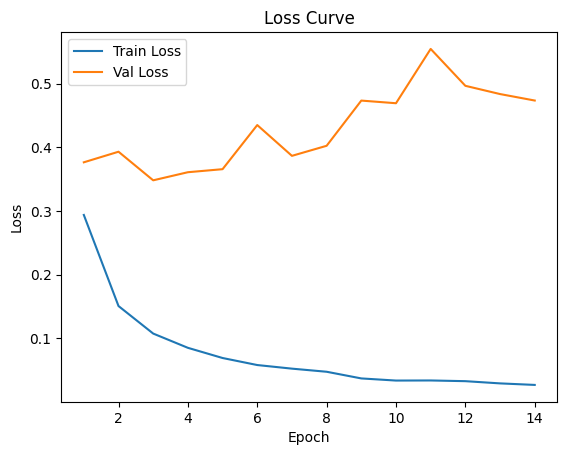

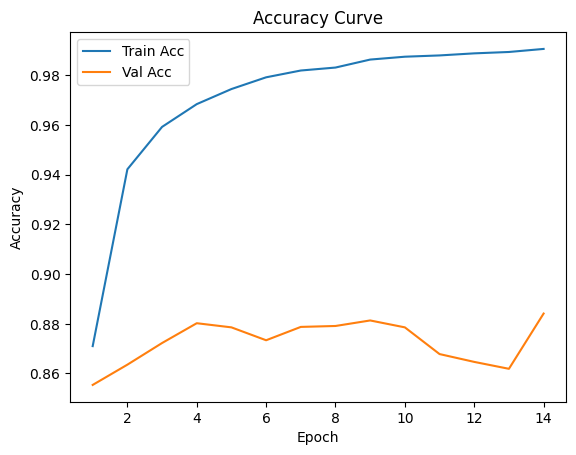

In [7]:
plot_history(history=history)

### Dự đoán trên test set

In [8]:
from src.training import predict_test

acc, all_preds, all_labels = predict_test(device=device, model=test_model, test_loader=test_loader)

KeyboardInterrupt: 

### Dự đoán ở video ngoài

In [9]:
from src.utilities import predict_video

train_tranform, eval_transform = get_transforms(cnf)

OUTSRC_VID_DIR = "outsrc_vid"

videos = os.listdir(OUTSRC_VID_DIR)

for vid in videos:

    video_path = os.path.join(OUTSRC_VID_DIR, vid)
    print(f"Prediction on {vid}")
    output = predict_video(test_model, video_path, eval_transform, device)


Prediction on 000_003.mp4
Average probability 0.2084859013557434
Video prediction: Real
Prediction on 001_870.mp4
Average probability 0.3067147210240364
Video prediction: Real
Prediction on 002_006.mp4
Average probability 0.049776176611582436
Video prediction: Real
Prediction on 003_000.mp4
Average probability 0.65100062203904
Video prediction: Fake
Prediction on 007_132.mp4
Average probability 0.9999976737790757
Video prediction: Fake
